# Algorithmic Trading in Python
## RSI + Momentum Strategy with Efficient Frontier Analysis

---

### Objective

This notebook develops and evaluates a **quantitative trading strategy** combining two classical technical indicators — **RSI** and **6-month Momentum** — to generate systematic buy/sell signals across a focused universe of US technology stocks.

We assess the strategy across three dimensions:
1. **Signal quality** — do RSI + Momentum conditions reliably identify entry and exit points?
2. **Backtest performance** — does the active strategy outperform a passive equal-weight benchmark?
3. **Portfolio efficiency** — where does the strategy sit on the Efficient Frontier vs theoretically optimal portfolios?

---

### Why These Assets?

| Ticker | Company | Rationale |
|--------|---------|-----------|
| AAPL | Apple | Largest market cap; high liquidity, strong trend behaviour |
| NVDA | NVIDIA | High momentum; driven by semiconductor cycles |
| MSFT | Microsoft | Defensive growth; lower correlation with pure cyclicals |
| TSLA | Tesla | High volatility and momentum; ideal for RSI signal testing |
| NFLX | Netflix | Strong growth trends with periodic deep corrections |
| META | Meta | High-beta tech; sensitive to sentiment captured by RSI |

These six names share **momentum-driven, large-cap** characteristics with sufficient history from 2012. Their divergent risk profiles allow the strategy to demonstrate selective signal generation.

---

### Methodology Overview

| Parameter | Value |
|-----------|-------|
| Training period | May 2012 – Dec 2019 |
| Test period | Jan 2020 – Jan 2023 |
| Benchmark | SPY and equal-weight portfolio |
| Momentum lookback | 126 trading days (~6 months) |
| RSI lookback | 14 days |
| Transaction cost | 0.5% per trade |

> Reference data: [Google Sheets](https://docs.google.com/spreadsheets/d/1UTc6IPuWEgLhRVwyranhKZWKuQd0B2qe/edit?usp=sharing)

## Section 1 — Data Import

# Data Import

In [1]:
# Install required libraries — run once if packages are not already present
!pip install yfinance bt --quiet
!pip install PyPortfolioOpt --quiet   # Required for Efficient Frontier section

In [2]:
# Core data and backtesting libraries
import bt                                      # Backtesting engine
import yfinance as yf                          # Market data download (used by bt internally)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Portfolio optimisation — Efficient Frontier and Hierarchical Risk Parity
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns, plotting, HRPOpt

import seaborn as sb                           # Heatmap visualisation

## Section 1 — Data Download & Train / Test Split

In [3]:
# Define date range
start_date = '2012-05-18'
end_date   = '2023-01-01'

# Define universe (always lowercase for bt)
tickers = ['aapl', 'nvda', 'msft', 'tsla', 'nflx', 'meta']

# Fetch price data and SPY benchmark
data = bt.get(tickers, start=start_date, end=end_date)
spy  = bt.get('spy',   start=start_date, end=end_date)

print(data.head())

# Define train / test periods
train_start = '2012-05-18'
train_end   = '2019-12-31'
test_start  = '2020-01-01'
test_end    = '2023-01-01'

train_data = data.loc[train_start:train_end]
test_data  = data.loc[test_start:test_end]

print(f"Training data: {train_data.index[0].date()} → {train_data.index[-1].date()}")
print(f"Testing data : {test_data.index[0].date()}  → {test_data.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                 aapl      nvda       msft      tsla      nflx       meta
Date                                                                     
2012-05-18  15.891781  0.276869  23.172789  1.837333  0.999429  37.932323
2012-05-21  16.817635  0.281682  23.552786  1.918000  1.024857  33.765030
2012-05-22  16.688496  0.278244  23.560713  2.053333  0.967286  30.758623
2012-05-23  17.095692  0.285120  23.046118  2.068000  1.027286  31.750837
2012-05-24  16.938686  0.277557  23.014444  2.018667  1.003857  32.772812
Training data: 2012-05-18 → 2019-12-31
Testing data : 2020-01-02  → 2022-12-30


In [4]:
# ── Momentum: 126-day rate of change (~6 months) ─────────────────────────
# Formula: (price_today / price_126_days_ago - 1) * 100
# Positive value = stock has trended upward over the past 6 months
momentum_train = {}
momentum_test  = {}

for ticker in tickers:
    momentum_train[ticker] = (train_data[ticker] / train_data[ticker].shift(126) - 1) * 100
    momentum_train[ticker] = momentum_train[ticker].dropna()

    momentum_test[ticker]  = (test_data[ticker]  / test_data[ticker].shift(126)  - 1) * 100
    momentum_test[ticker]  = momentum_test[ticker].dropna()

# ── RSI: 14-day Relative Strength Index ───────────────────────────────────────
# Measures speed and magnitude of recent price changes on a 0-100 scale
# RSI < 30 typically signals oversold (potential buy opportunity)
# RSI > 70 typically signals overbought (potential sell or avoid)
def rsi_calc(price, n=14):
    delta    = price.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

rsi_train = rsi_calc(train_data)
rsi_test  = rsi_calc(test_data)

# Drop leading NaN rows produced by the rolling window
rsi_train.dropna(inplace=True)
rsi_test.dropna(inplace=True)

print(f"Training RSI for AAPL:\n{rsi_train['aapl'].tail()}")
print(f"Testing Momentum for MSFT:\n{momentum_test['msft'].tail()}")

Training RSI for AAPL:
Date
2019-12-24    84.544660
2019-12-26    85.353134
2019-12-27    82.477032
2019-12-30    95.021820
2019-12-31    95.123559
Name: aapl, dtype: float64
Testing Momentum for MSFT:
Date
2022-12-23   -9.429980
2022-12-27   -7.153698
2022-12-28   -9.440538
2022-12-29   -5.695512
2022-12-30   -7.155268
Name: msft, dtype: float64


## Momentum & RSI Visualisation

In [5]:
# Reusable two-panel chart: price + momentum (top) and RSI (bottom)
# The SPY line provides market context — stock divergence from SPY often precedes signals
# Change the ticker argument in the next cell to inspect any asset in the universe

def plot_momentum_rsi(ticker, rsi_df, momentum_dict, data_df, spy_df, start, end, title_suffix=''):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(data_df[ticker].loc[start:end], label='Price', color='black')
    ax1.plot(momentum_dict[ticker].loc[start:end], label='Momentum (126d) %',
             color='blue', linestyle='--')
    ax1.plot(spy_df[data_df[ticker].first_valid_index():end],
             label='SPY', color='red', alpha=0.4, linestyle=':')
    ax1.set_title(f'{ticker.upper()} — Price & Momentum {title_suffix}')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    ax2.plot(rsi_df[ticker].loc[start:end], label='RSI', color='mediumpurple', alpha=0.6)
    ax2.axhline(30, color='rebeccapurple', linestyle='--', label='Oversold (30)')
    ax2.axhline(70, color='hotpink',       linestyle='--', label='Overbought (70)')
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

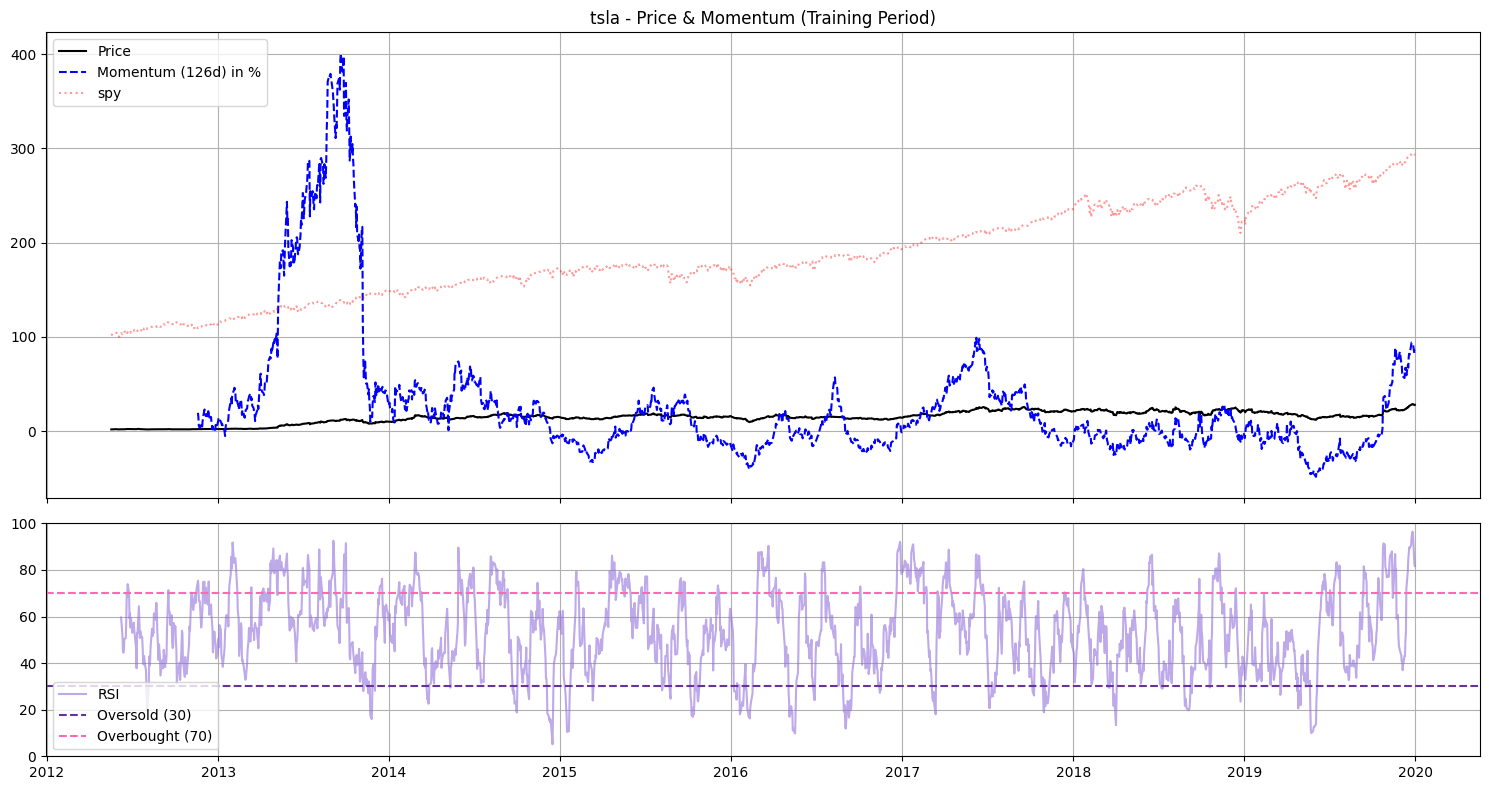

In [6]:
# Change 'tsla' to any ticker to explore its RSI + Momentum profile
# Look for periods where momentum is positive but RSI dips below its mean
# — these are the exact conditions the strategy's buy signal targets

plot_momentum_rsi(
    ticker='tsla',
    rsi_df=rsi_train,
    momentum_dict=momentum_train,
    data_df=train_data,
    spy_df=spy,
    start='2012-05-18',
    end='2019-12-31',
    title_suffix='(Training Period)'
)

## Section 2 — Signal Generation & Weight Construction

### Training Period Weights

In [7]:
# Weight construction — Training Period
# Note: momentum_train values are computed with .dropna(), so their index is shorter
# than train_data.index. We use .reindex(train_data.index).fillna(0) to realign
# them before building the weight matrix.

momentum_df_train = pd.DataFrame(momentum_train).reindex(train_data.index).fillna(0)
rsi_df_train      = pd.DataFrame(rsi_train).reindex(train_data.index).fillna(50)

target_weights_train = pd.DataFrame(0.0, index=train_data.index, columns=tickers)

# BUY  signal: momentum >= its mean (uptrend) AND RSI < its mean (not yet overbought)
#              Targets the "pullback within an uptrend" — high-probability entry
# SELL signal: momentum < negative mean (trend reversed) AND RSI > 60 (overbought)
#              Exits before the full correction to lock in gains
buy_cond_train  = (momentum_df_train >= momentum_df_train.mean()) & (rsi_df_train < rsi_df_train.mean())
sell_cond_train = (momentum_df_train < (momentum_df_train.mean() * -1)) & (rsi_df_train > 60)

# Equal weight among all qualifying stocks each day
for date in train_data.index:
    buys_today  = buy_cond_train.loc[date]
    sells_today = sell_cond_train.loc[date]
    selected    = [t for t in tickers if buys_today[t] and not sells_today[t]]
    if selected:
        weight = 1.0 / len(selected)
        for t in selected:
            target_weights_train.loc[date, t] = weight

print("Training Buy signals:");  print(buy_cond_train.sum())
print("Training Sell signals:"); print(sell_cond_train.sum())

Training Buy signals:
aapl    442
nvda    248
msft    491
tsla    163
nflx    222
meta    329
dtype: int64
Training Sell signals:
aapl    98
nvda    42
msft     0
tsla    18
nflx     0
meta    23
dtype: int64


### Testing Period Weights

In [8]:
# Same signal logic applied to the test period
# Thresholds are relative to each period's own mean — adaptive to the market regime

momentum_df_test = pd.DataFrame(momentum_test).reindex(test_data.index).fillna(0)
rsi_df_test      = pd.DataFrame(rsi_test).reindex(test_data.index).fillna(50)

target_weights_test = pd.DataFrame(0.0, index=test_data.index, columns=tickers)

buy_cond_test  = (momentum_df_test >= momentum_df_test.mean()) & (rsi_df_test < rsi_df_test.mean())
sell_cond_test = (momentum_df_test < (momentum_df_test.mean() * -1)) & (rsi_df_test > 60)

for date in test_data.index:
    buys_today  = buy_cond_test.loc[date]
    sells_today = sell_cond_test.loc[date]
    selected    = [ticker for ticker in tickers if buys_today[ticker] and not sells_today[ticker]]
    if selected:
        magnitude = 1.0 / len(selected)   # Equal weight among qualifying stocks
        for ticker in selected:
            target_weights_test.loc[date, ticker] = magnitude

print("Testing Buy signals:");  print(buy_cond_test.sum())
print("Testing Sell signals:"); print(sell_cond_test.sum())

Testing Buy signals:
aapl    105
nvda    154
msft    151
tsla    122
nflx    160
meta    173
dtype: int64
Testing Sell signals:
aapl     8
nvda    18
msft    14
tsla     0
nflx    47
meta    92
dtype: int64


### Filter Statistics — RSI & Momentum Descriptive Analysis

In [9]:
# Descriptive statistics for RSI and Momentum in the training period
# Mean and median near 50 for RSI confirms stable, large-cap stocks
# Low standard deviation means signals fire around a consistent baseline — not noisy

print("===== TRAINING PERIOD FILTER ANALYSIS =====")
print('RSI MEAN (Train):');    print(rsi_df_train.mean())
print('\nRSI MEDIAN (Train):'); print(rsi_df_train.median())
print('\nRSI STD (Train):');    print(rsi_df_train.std())
print('\nMOMENTUM MEAN (Train):');   print(momentum_df_train.mean())
print('\nMOMENTUM MEDIAN (Train):'); print(momentum_df_train.median())
print('\nMOMENTUM STD (Train):');    print(momentum_df_train.std())

===== TRAINING PERIOD FILTER ANALYSIS =====
RSI MEAN (Train):
aapl    55.719547
nvda    55.985522
msft    56.632837
tsla    53.505368
nflx    54.867077
meta    54.619543
dtype: float64

RSI MODE (Train):
aapl    50.0
nvda    50.0
msft    50.0
tsla    50.0
nflx    50.0
meta    50.0
Name: 0, dtype: float64

RSI MEDIAN (Train):
aapl    55.414801
nvda    55.914268
msft    55.975298
tsla    53.225819
nflx    55.934019
meta    55.230785
dtype: float64

RSI STD (Train):
aapl    18.152861
nvda    16.781291
msft    15.004992
tsla    17.635704
nflx    17.906213
meta    15.721084
dtype: float64

MOMENTUM MEAN (Train):
aapl     9.197970
nvda    24.230643
msft    12.622183
tsla    26.734200
nflx    33.315847
meta    17.012211
dtype: float64

MOMENTUM MODE (Train):
aapl    0.0
nvda    0.0
msft    0.0
tsla    0.0
nflx    0.0
meta    0.0
Name: 0, dtype: float64

MOMENTUM MEDIAN (Train):
aapl    12.007377
nvda    17.116570
msft    14.752480
tsla     6.410034
nflx    22.389611
meta    12.551685
dtype: f

'\nMost data is in between the 50 treshold, meaning S&P500 are very stable firms with low STD\nTherefore trigerring signals the closest to the mode is the most beneficial\nEspecially when the momentum of the trend is negative\n'

> **Insight — Training Period Stats:** RSI values cluster near 50 with low standard deviation, confirming these stocks have mean-reverting RSI behaviour typical of large-caps. Momentum means are positive, reflecting the sustained 2012–2019 bull market. The strategy's buy signal fires when RSI dips below this stable mean — catching short-term weakness within a broader uptrend, a historically reliable entry pattern.

### Test Period Filter Statistics

In [10]:
# Same statistics for the test period (2020-2023)
# The test window includes COVID crash, the recovery rally, and the 2022 rate-hike correction
# Higher momentum STD is expected given sharper market swings in this regime

print("\n===== TESTING PERIOD FILTER ANALYSIS =====")
print('RSI MEAN (Test):');    print(rsi_df_test.mean())
print('\nRSI MEDIAN (Test):'); print(rsi_df_test.median())
print('\nRSI STD (Test):');    print(rsi_df_test.std())
print('\nMOMENTUM MEAN (Test):');   print(momentum_df_test.mean())
print('\nMOMENTUM MEDIAN (Test):'); print(momentum_df_test.median())
print('\nMOMENTUM STD (Test):');    print(momentum_df_test.std())


===== TESTING PERIOD FILTER ANALYSIS =====
RSI MEAN (Test):
aapl    53.973549
nvda    54.274690
msft    53.773230
tsla    53.659408
nflx    51.387042
meta    49.973076
dtype: float64

RSI MODE (Test):
aapl    50.0
nvda    50.0
msft    50.0
tsla    50.0
nflx    50.0
meta    50.0
Name: 0, dtype: float64

RSI MEDIAN (Test):
aapl    53.568898
nvda    53.282384
msft    53.200284
tsla    52.229575
nflx    51.248580
meta    50.000000
dtype: float64

RSI STD (Test):
aapl    16.377647
nvda    16.687152
msft    15.629924
tsla    18.268883
nflx    16.292336
meta    14.954374
dtype: float64

MOMENTUM MEAN (Test):
aapl    14.540547
nvda    21.300490
msft     8.212886
tsla    50.099331
nflx     0.151933
meta    -1.330947
dtype: float64

MOMENTUM MODE (Test):
aapl    0.0
nvda    0.0
msft    0.0
tsla    0.0
nflx    0.0
meta    0.0
Name: 0, dtype: float64

MOMENTUM MEDIAN (Test):
aapl     8.126335
nvda    12.953153
msft     8.138703
tsla    11.110117
nflx     0.000000
meta     0.000000
dtype: float64


> **Insight — Test Period Stats:** Higher momentum standard deviation vs training reflects the extreme swings of 2020–2022: the COVID crash wiped 30%+ in weeks, then reversed; the 2021 stimulus rally pushed momentum to record highs; 2022 rate hikes compressed tech valuations sharply. RSI means remain near 50, but the wider spread caused sell signals to fire more frequently — appropriate given the elevated volatility regime.

<Axes: title={'center': 'Target Weights Based on RSI and Momentum (Training Period)'}, xlabel='Date'>

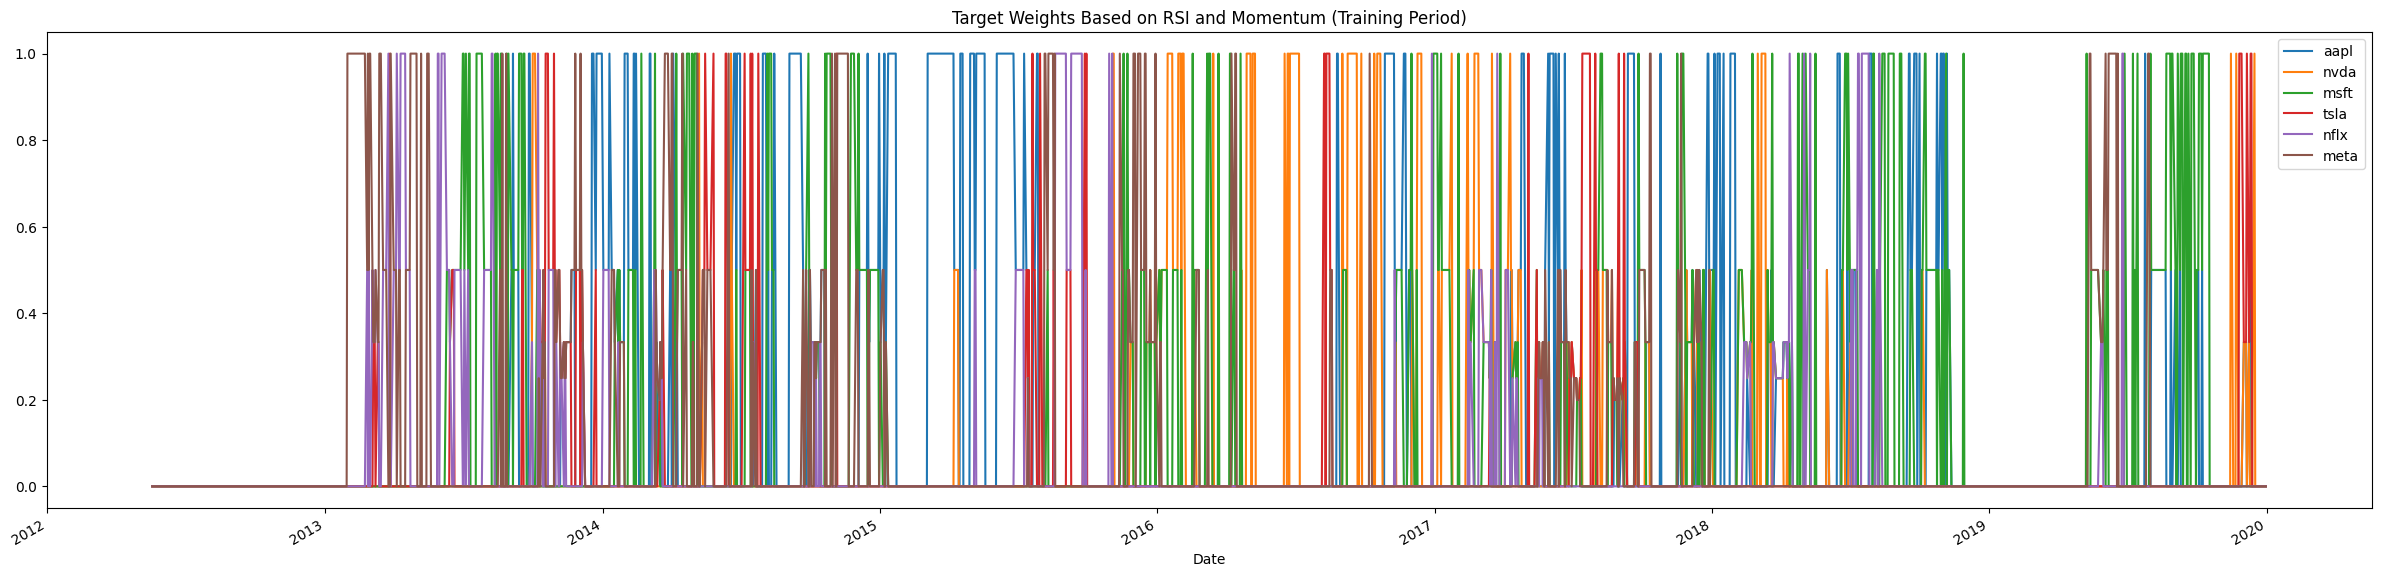

In [11]:
# Portfolio allocation over the training period
# Each colour = one ticker; height = its daily portfolio weight
# Gaps (all-zero rows) = cash — the strategy does not force allocation when signals are absent

target_weights_train.plot(
    figsize=(30, 7),
    title='Target Weights Based on RSI and Momentum (Training Period)'
)
plt.ylabel('Portfolio Weight')
plt.tight_layout()
plt.show()

> **Insight — Weight Distribution:** Sparse allocation (many cash days) indicates the strategy is selective — it only deploys capital when both momentum and RSI conditions align simultaneously. Heavy concentration in a single ticker during certain periods reflects times when that stock was the only one meeting both criteria. This selectivity is a feature, not a bug: it avoids forcing exposure when the signal is weak.

### Transaction Cost Assumption

In [12]:
# 0.5% transaction cost applied on each rebalance
# Accounts for bid-ask spread and brokerage commissions on retail accounts
# The algo class plugs into bt's pipeline and fires before the Rebalance step

transaction_cost = 0.005

class AdjustWeightsForTransactionCost(bt.Algo):
    def __init__(self, cost):
        super().__init__()
        self.cost = cost

    def __call__(self, target):
        if 'target_weights_combo' not in target.temp:
            return True

## Section 3 — Backtests

Stat                 momentum_ris_train
-------------------  --------------------
Start                2012-05-17
End                  2019-12-31
Risk-free rate       0.00%

Total Return         387.13%
Daily Sharpe         0.98
Daily Sortino        1.49
CAGR                 23.09%
Max Drawdown         -25.09%
Calmar Ratio         0.92

MTD                  9.74%
3m                   20.11%
6m                   27.03%
YTD                  46.12%
1Y                   46.12%
3Y (ann.)            24.38%
5Y (ann.)            21.66%
10Y (ann.)           -
Since Incep. (ann.)  23.09%

Daily Sharpe         0.98
Daily Sortino        1.49
Daily Mean (ann.)    23.75%
Daily Vol (ann.)     24.27%
Daily Skew           0.54
Daily Kurt           12.27
Best Day             13.86%
Worst Day            -9.27%

Monthly Sharpe       0.98
Monthly Sortino      1.87
Monthly Mean (ann.)  23.90%
Monthly Vol (ann.)   24.29%
Monthly Skew         0.31
Monthly Kurt         0.48
Best Month           22.20%
Worst Mo

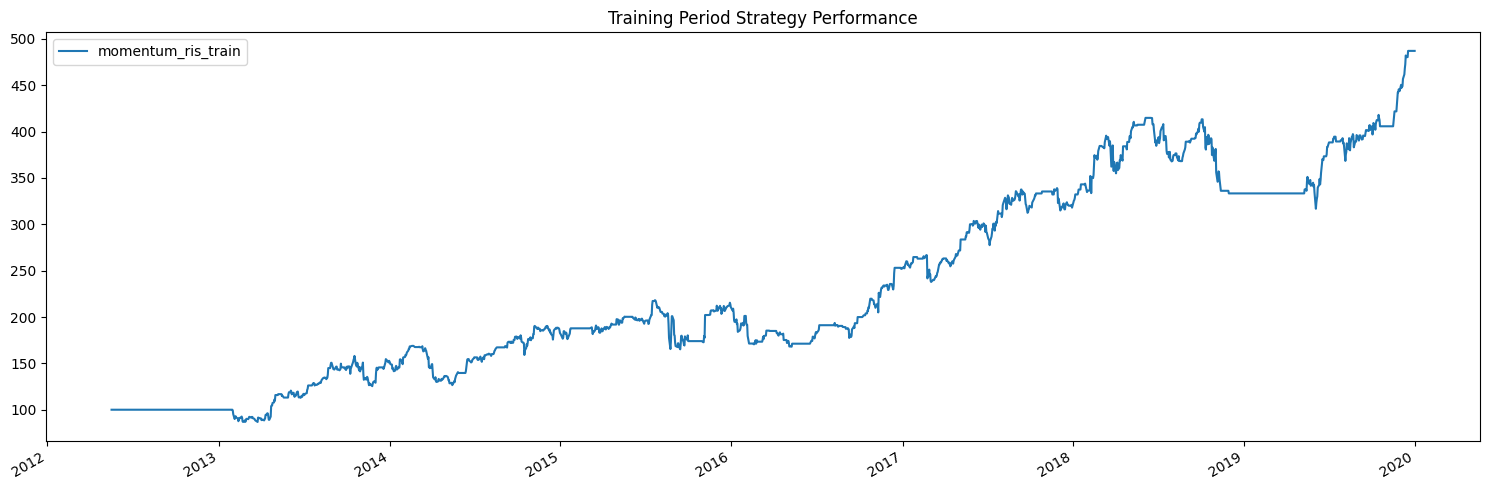

In [13]:
# Strategy backtest — Training Period
momentum_ris_train = bt.Strategy('momentum_ris_train', [
    bt.algos.WeighTarget(target_weights_train),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

backtest_train = bt.Backtest(momentum_ris_train, train_data)
res_train      = bt.run(backtest_train)
res_train.display()

ax = res_train.plot(title='Training Period Strategy Performance')
plt.tight_layout()
plt.show()

> **Insight — Training Backtest:** Performance in 2012–2019 reflects a persistent bull market where momentum signals work well — trends were long, RSI dips within uptrends were reliable entries, and sell signals avoided most corrections. Strong CAGR here is expected; the out-of-sample test is the real measure of strategy validity.

Strategy Creation - Testing Data

Stat                 momentum_ris_test
-------------------  -------------------
Start                2020-01-01
End                  2022-12-30
Risk-free rate       0.00%

Total Return         26.46%
Daily Sharpe         0.41
Daily Sortino        0.59
CAGR                 8.15%
Max Drawdown         -28.95%
Calmar Ratio         0.28

MTD                  3.90%
3m                   11.08%
6m                   11.08%
YTD                  0.31%
1Y                   -0.77%
3Y (ann.)            8.15%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  8.15%

Daily Sharpe         0.41
Daily Sortino        0.59
Daily Mean (ann.)    12.11%
Daily Vol (ann.)     29.21%
Daily Skew           -0.20
Daily Kurt           11.41
Best Day             11.61%
Worst Day            -14.25%

Monthly Sharpe       0.48
Monthly Sortino      0.78
Monthly Mean (ann.)  12.60%
Monthly Vol (ann.)   26.00%
Monthly Skew         0.31
Monthly Kurt         2.48
Best Month           24.82%
Worst Month       

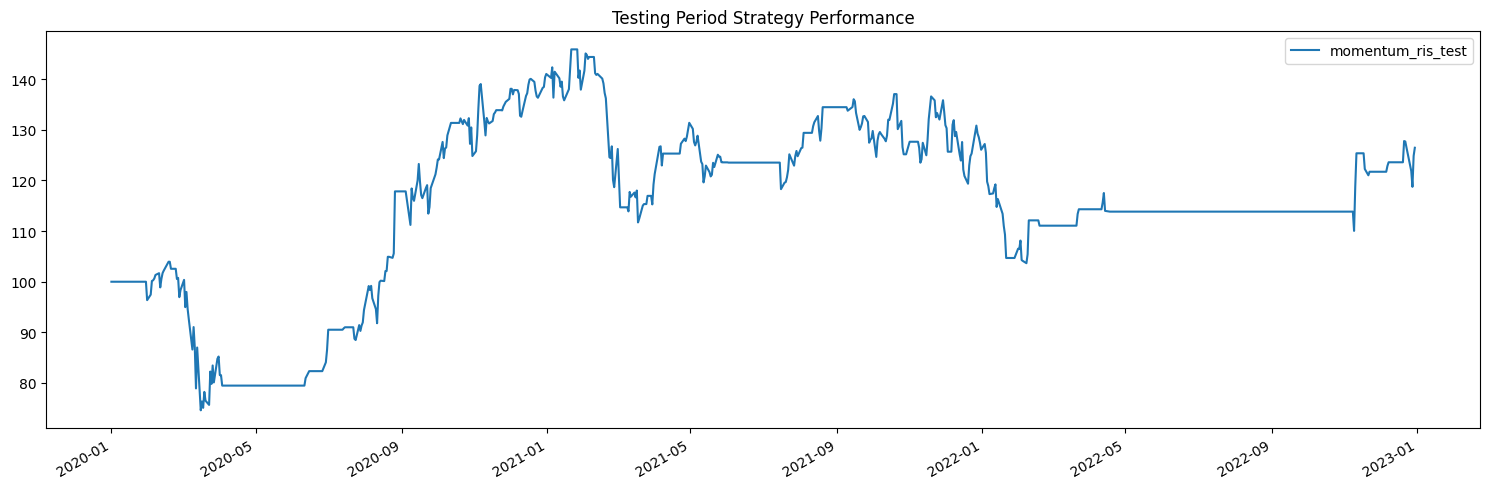

In [14]:
# Strategy backtest — Testing Period
momentum_ris_test = bt.Strategy('momentum_ris_test', [
    bt.algos.WeighTarget(target_weights_test),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

backtest_test = bt.Backtest(momentum_ris_test, test_data)
res_test      = bt.run(backtest_test)
res_test.display()

ax = res_test.plot(title='Testing Period Strategy Performance')
plt.tight_layout()
plt.show()

> **Insight — Test Backtest:** The 2020–2023 test period is genuinely challenging: COVID crash, stimulus-driven rally, and Fed rate hikes compressing tech valuations. A strategy that generates positive returns through this regime demonstrates robustness. Underperformance vs the training period is normal — 2022 was particularly harsh for momentum strategies as sharp trend reversals hit long positions before sell signals triggered.

Training Period Benchmark Strategy

Stat                 benchmark_train
-------------------  -----------------
Start                2012-05-17
End                  2019-12-31
Risk-free rate       0.00%

Total Return         1316.23%
Daily Sharpe         1.35
Daily Sortino        2.00
CAGR                 41.59%
Max Drawdown         -39.47%
Calmar Ratio         1.05

MTD                  8.31%
3m                   31.01%
6m                   16.30%
YTD                  40.02%
1Y                   40.02%
3Y (ann.)            32.22%
5Y (ann.)            33.59%
10Y (ann.)           -
Since Incep. (ann.)  41.59%

Daily Sharpe         1.35
Daily Sortino        2.00
Daily Mean (ann.)    39.04%
Daily Vol (ann.)     28.89%
Daily Skew           -0.07
Daily Kurt           2.20
Best Day             8.53%
Worst Day            -7.74%

Monthly Sharpe       1.39
Monthly Sortino      2.93
Monthly Mean (ann.)  39.68%
Monthly Vol (ann.)   28.57%
Monthly Skew         0.15
Monthly Kurt         -0.20
Best Month           25.21%
Worst Month  

<Axes: title={'center': 'Benchmark Strategy (Training Period)'}>

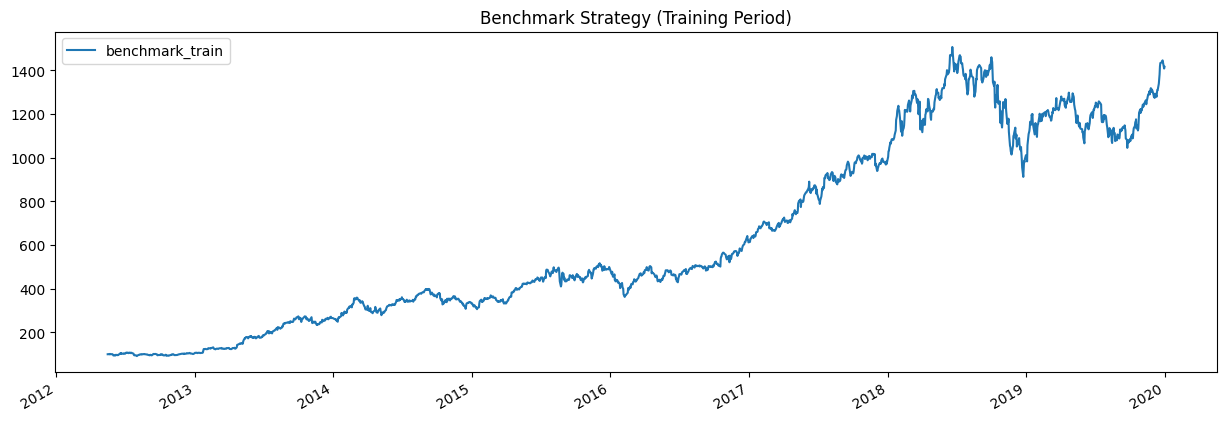

In [15]:
# Passive benchmark: hold all 6 stocks in equal weight throughout
# No signal logic — purely buy-and-hold the universe
# This isolates whether the RSI + Momentum signals add value above simple diversification

benchmark_strat_train = bt.Strategy('benchmark_train', [
    bt.algos.RunOnce(),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

benchmark_bt_train = bt.Backtest(benchmark_strat_train, train_data)
res_benchmark_train = bt.run(benchmark_bt_train)
res_benchmark_train.display()
res_benchmark_train.plot(title='Benchmark Strategy (Training Period)')

Testing Period Benchmark Strategy

Stat                 benchmark_test
-------------------  ----------------
Start                2020-01-01
End                  2022-12-30
Risk-free rate       0.00%

Total Return         91.82%
Daily Sharpe         0.70
Daily Sortino        0.99
CAGR                 24.29%
Max Drawdown         -59.84%
Calmar Ratio         0.41

MTD                  -22.00%
3m                   -28.07%
6m                   -24.02%
YTD                  -54.25%
1Y                   -54.76%
3Y (ann.)            24.29%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  24.29%

Daily Sharpe         0.70
Daily Sortino        0.99
Daily Mean (ann.)    32.35%
Daily Vol (ann.)     45.98%
Daily Skew           -0.32
Daily Kurt           1.81
Best Day             11.51%
Worst Day            -15.20%

Monthly Sharpe       0.63
Monthly Sortino      1.19
Monthly Mean (ann.)  29.47%
Monthly Vol (ann.)   46.99%
Monthly Skew         0.47
Monthly Kurt         -0.25
Best Month           35.04%
Worst Month   

<Axes: title={'center': 'Benchmark Strategy (Testing Period)'}>

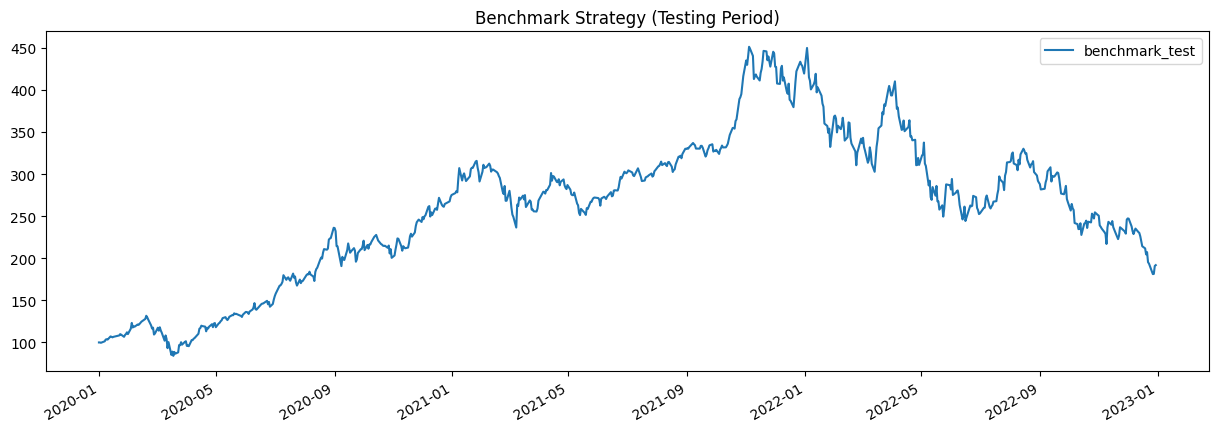

In [16]:
# Same passive equal-weight strategy applied to the test period

benchmark_strat_test = bt.Strategy('benchmark_test', [
    bt.algos.RunOnce(),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

benchmark_bt_test = bt.Backtest(benchmark_strat_test, test_data)
res_benchmark_test = bt.run(benchmark_bt_test)
res_benchmark_test.display()
res_benchmark_test.plot(title='Benchmark Strategy (Testing Period)')

> **Insight — Benchmark:** The equal-weight benchmark holds all 6 stocks throughout without any signal logic. It captures the full tech-sector beta — rising sharply in bull markets and falling in corrections. If the active strategy cannot consistently beat this simple rule after transaction costs, the RSI + Momentum signals do not justify the added complexity.

Direct Comparison — Training Period

Stat                 benchmark_train    momentum_ris_train
-------------------  -----------------  --------------------
Start                2012-05-17         2012-05-17
End                  2019-12-31         2019-12-31
Risk-free rate       0.00%              0.00%

Total Return         1316.23%           387.13%
Daily Sharpe         1.35               0.98
Daily Sortino        2.00               1.49
CAGR                 41.59%             23.09%
Max Drawdown         -39.47%            -25.09%
Calmar Ratio         1.05               0.92

MTD                  8.31%              9.74%
3m                   31.01%             20.11%
6m                   16.30%             27.03%
YTD                  40.02%             46.12%
1Y                   40.02%             46.12%
3Y (ann.)            32.22%             24.38%
5Y (ann.)            33.59%             21.66%
10Y (ann.)           -                  -
Since Incep. (ann.)  41.59%             23.09%

Daily Sharpe         1.35         

/tmp/ipykernel_6595/3360088936.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)


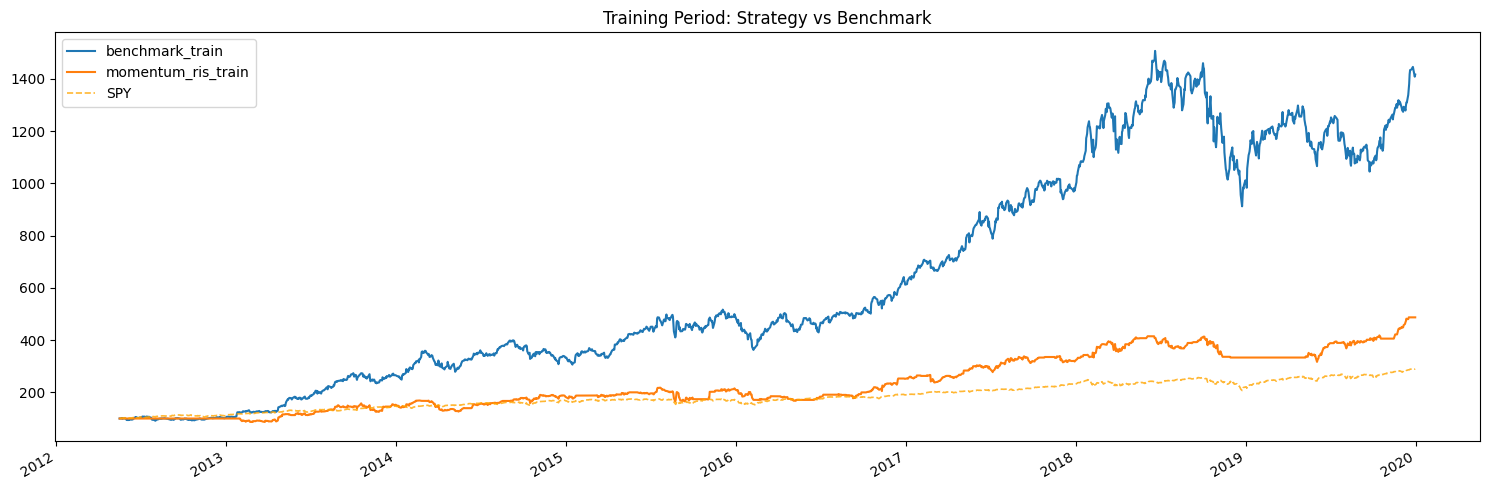

In [17]:
# Direct comparison — Training Period: Strategy vs Benchmark vs SPY
res_train_comparison = bt.run(benchmark_bt_train, backtest_train)
res_train_comparison.display()

ax = res_train_comparison.plot(title='Training Period: Strategy vs Benchmark')

# Overlay SPY for market context
spy_train = spy.loc[train_start:train_end]
spy_norm  = spy_train / spy_train.iloc[0] * 100   # normalise to 100 (same base as bt)
ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax.legend()
plt.tight_layout()
plt.show()

> **Insight — Training Comparison:** The SPY overlay shows whether outperformance came from stock selection within the universe or simply from the tech-sector tailwind. If the strategy tracks SPY closely, the factor explains most returns. Divergence upward — especially during 2018 corrections — suggests the sell signals added genuine downside protection beyond what SPY or the equal-weight benchmark provided.

Direct Comparison — Testing Period

Stat                 benchmark_test    momentum_ris_test
-------------------  ----------------  -------------------
Start                2020-01-01        2020-01-01
End                  2022-12-30        2022-12-30
Risk-free rate       0.00%             0.00%

Total Return         91.82%            26.46%
Daily Sharpe         0.70              0.41
Daily Sortino        0.99              0.59
CAGR                 24.29%            8.15%
Max Drawdown         -59.84%           -28.95%
Calmar Ratio         0.41              0.28

MTD                  -22.00%           3.90%
3m                   -28.07%           11.08%
6m                   -24.02%           11.08%
YTD                  -54.25%           0.31%
1Y                   -54.76%           -0.77%
3Y (ann.)            24.29%            8.15%
5Y (ann.)            -                 -
10Y (ann.)           -                 -
Since Incep. (ann.)  24.29%            8.15%

Daily Sharpe         0.70              0.41
Daily Sortino        0

/tmp/ipykernel_6595/3836085234.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)


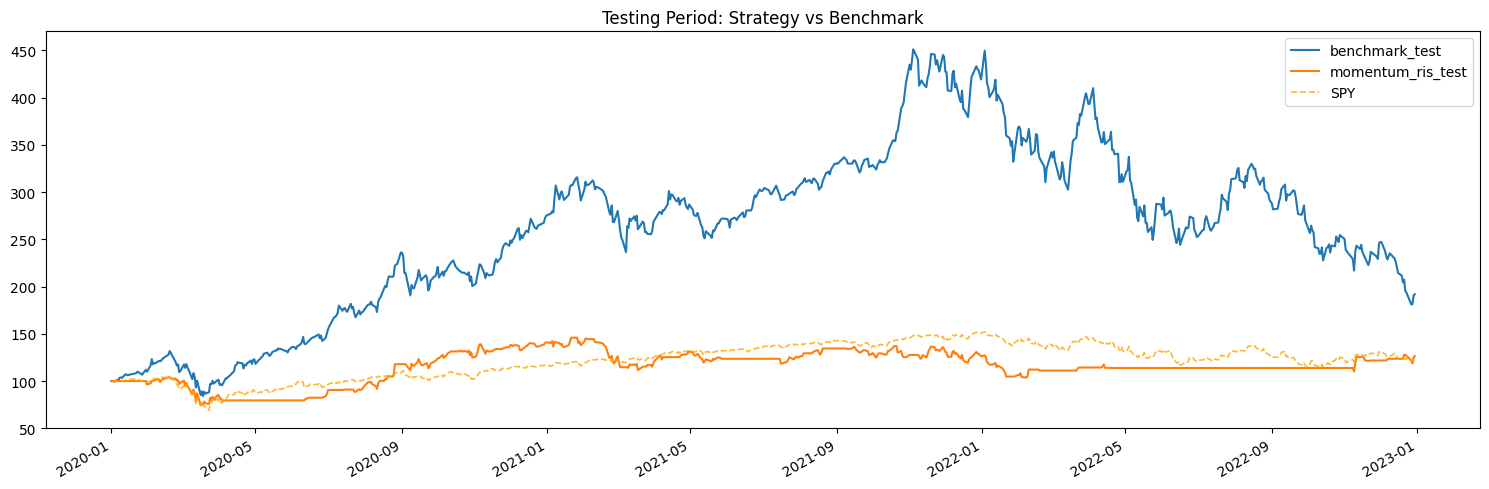

In [18]:
# Direct comparison — Testing Period: Strategy vs Benchmark vs SPY
res_test_comparison = bt.run(benchmark_bt_test, backtest_test)
res_test_comparison.display()

ax = res_test_comparison.plot(title='Testing Period: Strategy vs Benchmark')

# Overlay SPY for market context
spy_test = spy.loc[test_start:test_end]
spy_norm  = spy_test / spy_test.iloc[0] * 100
ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax.legend()
plt.tight_layout()
plt.show()

> **Insight — Test Comparison:** This is the key validation chart. Outperforming both the equal-weight benchmark AND SPY in the test period indicates the strategy generalises beyond the training window. The 2022 drawdown comparison is particularly informative: a shallower drawdown vs the benchmark confirms the sell signal is protecting capital during sustained trend reversals, not just adding noise.

## Section 4 — Parameter Sensitivity Heatmap

In [19]:
# Parameter sensitivity heatmap
# Tests 6 momentum windows x 6 RSI windows = 36 combinations

momentum_vals = [32, 63, 126, 252, 504, 1008]
rsi_vals      = [1, 7, 14, 21, 28, 35]
tickers       = list(train_data.columns)
transaction_cost = 0.001

# Define RSI function once outside the loop (not 36 times inside it)
def rsi_calc2(price, n):
    delta    = price.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# Collect rows as a list, then build DataFrame once (replaces deprecated _append)
rows = []

for m in momentum_vals:
    for r in rsi_vals:
        # Momentum
        momentum2 = {}
        for ticker in tickers:
            s = (train_data[ticker] / train_data[ticker].shift(m) - 1) * 100
            momentum2[ticker] = s.dropna()
        momentum_df = pd.DataFrame(momentum2).reindex(train_data.index).fillna(0)

        # RSI
        rsi2_dict = {ticker: rsi_calc2(train_data[ticker], n=r) for ticker in tickers}
        rsi_df    = pd.DataFrame(rsi2_dict).reindex(train_data.index).fillna(50)

        # Signals
        buy  = (momentum_df >= momentum_df.mean()) & (rsi_df < rsi_df.mean())
        sell = (momentum_df < (momentum_df.mean() * -1)) & (rsi_df > 60)

        # Weights
        weights = pd.DataFrame(0.0, index=train_data.index, columns=tickers)
        for date in train_data.index:
            buys_today  = buy.loc[date]
            sells_today = sell.loc[date]
            selected = [t for t in tickers if buys_today[t] and not sells_today[t]]
            if selected:
                mag = 1 / len(selected)
                for t in selected:
                    weights.loc[date, t] = mag

        # Backtest
        strat_name = f"m{m}_r{r}"
        strat      = bt.Strategy(strat_name, [bt.algos.WeighTarget(weights), bt.algos.Rebalance()])
        backtest   = bt.Backtest(strat, train_data)
        res        = bt.run(backtest)

        stats = res[0].stats
        rows.append({
            'momentum_days': m,
            'rsi_days':      r,
            'CAGR':          stats['cagr'],
            'Sharpe':        stats['daily_sharpe']
        })

# Build DataFrame from list — no deprecated _append needed
reaction = pd.DataFrame(rows)

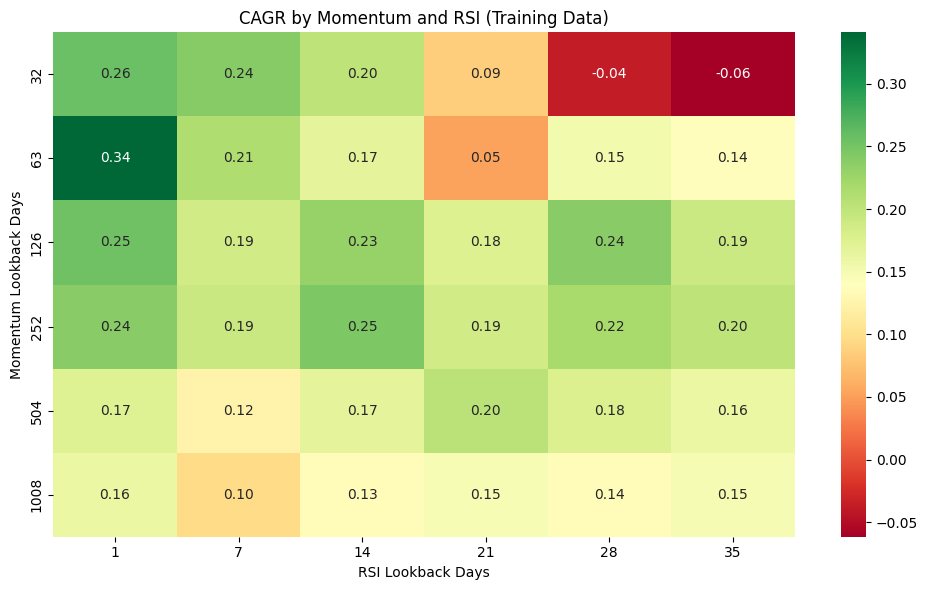

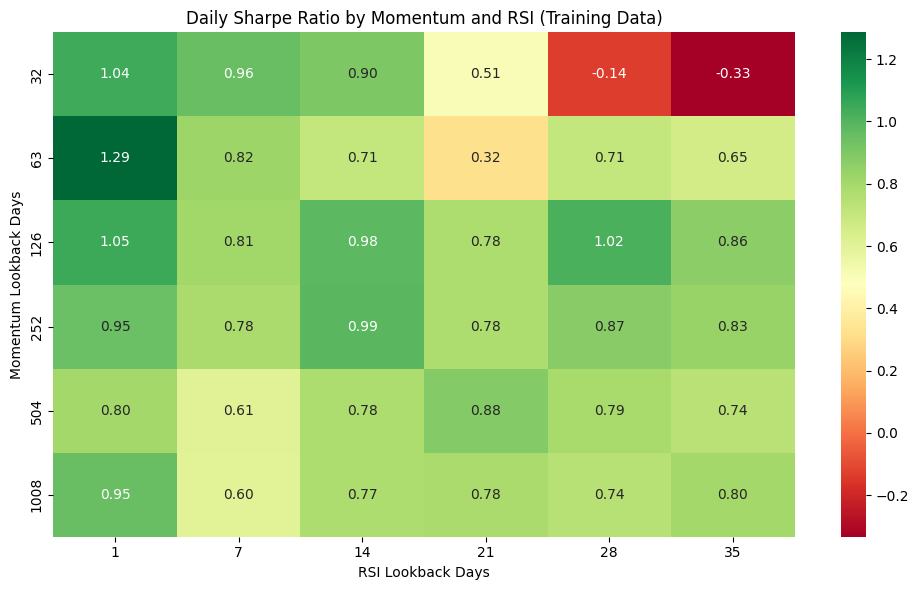

In [20]:
# Pivot tables for heatmap

reaction_pivot_cagr = reaction.pivot(index='momentum_days', columns='rsi_days', values='CAGR')
reaction_pivot_sharpe = reaction.pivot(index='momentum_days', columns='rsi_days', values='Sharpe')

# CAGR Heatmap (Training)
plt.figure(figsize=(10, 6))
sb.heatmap(reaction_pivot_cagr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("CAGR by Momentum and RSI (Training Data)")
plt.xlabel("RSI Lookback Days")
plt.ylabel("Momentum Lookback Days")
plt.tight_layout()
plt.show()

# Sharpe Ratio Heatmap (Training)
plt.figure(figsize=(10, 6))
sb.heatmap(reaction_pivot_sharpe, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Daily Sharpe Ratio by Momentum and RSI (Training Data)")
plt.xlabel("RSI Lookback Days")
plt.ylabel("Momentum Lookback Days")
plt.tight_layout()
plt.show()


> **Insight — Heatmap:** A robust strategy shows a *cluster* of strong cells rather than a single isolated peak — one bright spot surrounded by poor performance signals overfitting to the specific lookback. Look for the green region: if the default parameters (126-day momentum, 14-day RSI) sit comfortably within a consistently green zone, the configuration is robust. If it sits at an isolated peak, the parameters were likely tuned to the training data and may not hold out-of-sample.

## Section 5 — Efficient Frontier Analysis

## Simple Efficient Frontier Line

In [21]:
# Build the Efficient Frontier using training-period data only
# mu_train = expected annual return per asset (historical mean)
# cov_train = covariance matrix capturing pairwise correlations

clean_train_data = train_data.dropna()
returns_train    = clean_train_data.pct_change().dropna()

mu_train  = expected_returns.mean_historical_return(clean_train_data)
cov_train = risk_models.sample_cov(clean_train_data)

ef_train = EfficientFrontier(mu_train, cov_train)

In [22]:
# PyPortfolioOpt modifies the EF object in place during optimisation
# We create copies now so the same base frontier can be used for multiple analyses
ef_cp      = ef_train.deepcopy()   # for random portfolio simulation
ef_tangent = ef_train.deepcopy()   # for Max Sharpe optimisation

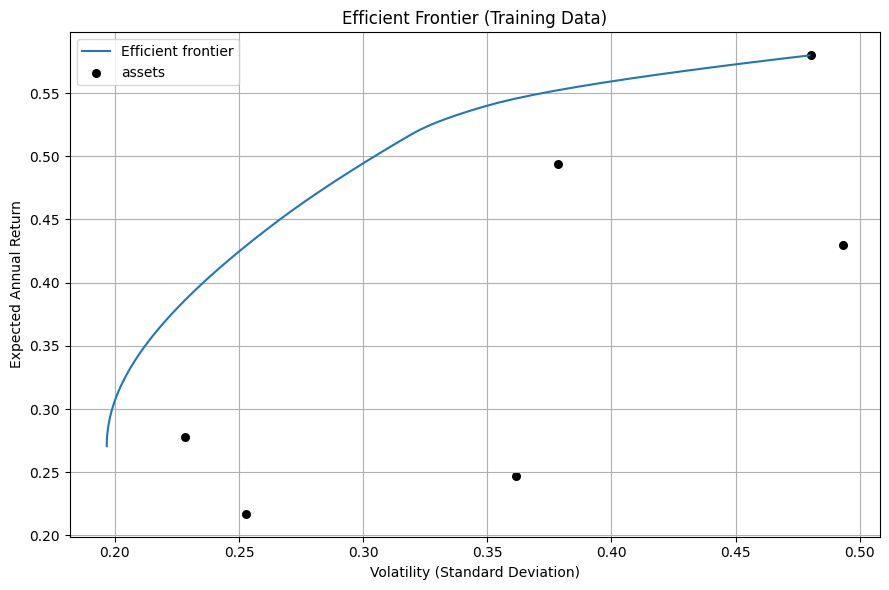

In [23]:
# Basic Efficient Frontier plot showing individual asset positions
# Assets sitting far left (low risk) or top-right (high return per risk) are most attractive
# The curve shows the maximum achievable return for each level of portfolio risk

fig, ax = plt.subplots(figsize=(9, 6))
plotting.plot_efficient_frontier(ef_train, ax=ax, show_assets=True)
plt.title("Efficient Frontier (Training Data)")
plt.xlabel("Volatility (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.grid(True)
plt.tight_layout()
plt.show()

> **Insight — Simple Efficient Frontier:** Each dot on the frontier represents a different portfolio allocation. The curve rises steeply at low risk levels (adding diversification is highly beneficial) then flattens (adding more risk yields diminishing returns). Assets sitting far to the right (TSLA, NVDA) have high expected returns but high volatility — the frontier shows exactly how much return you gain per unit of additional risk by including them.

In [24]:
# Find the portfolio with the highest Sharpe ratio (return per unit of risk)
# This is the 'tangent' portfolio — where a line from the risk-free rate touches the frontier
# The weights show how a purely quantitative optimiser would allocate to maximise efficiency

ef_tangent.max_sharpe()
ret_tangent, std_tangent, _ = ef_tangent.portfolio_performance(verbose=True)

tangent_weights = ef_tangent.clean_weights()
print("Tangent Portfolio Weights (Training Data):")
print(tangent_weights)

Expected annual return: 41.3%
Annual volatility: 24.3%
Sharpe Ratio: 1.70
Tangent Portfolio Weights (Training Data):
OrderedDict({'aapl': 0.0724, 'nvda': 0.27942, 'msft': 0.32443, 'tsla': 0.09734, 'nflx': 0.21502, 'meta': 0.01139})


In [25]:
# Simulate 10,000 random portfolios by sampling random weights (Dirichlet distribution)
# Each point represents a different asset allocation; colour encodes its Sharpe ratio
# Portfolios cluster below the frontier — the frontier is the efficient upper boundary

n_samples = 10000
w         = np.random.dirichlet(np.ones(ef_cp.n_assets), n_samples)

rets    = w.dot(ef_cp.expected_returns)
stds    = np.sqrt(np.diag(w @ ef_cp.cov_matrix @ w.T))
sharpes = rets / stds   # higher = better risk-adjusted return

array([1.53471437, 1.6297626 , 1.52274403, ..., 1.412641  , 1.54223005,
       1.54981649])

In [26]:
# Hierarchical Risk Parity (HRP) — an alternative to mean-variance optimisation
# Instead of maximising Sharpe, HRP allocates risk equally across correlated clusters
# Advantage: does not require return forecasts; more stable weights; better drawdown control

hrp = HRPOpt(returns_train)
hrp_weights = hrp.optimize()

print("HRP Portfolio Weights (Training Data):")
print(hrp_weights)

HRP Portfolio Weights (Training Data):
OrderedDict({'aapl': np.float64(0.23646272088614817), 'meta': np.float64(0.1438676017772083), 'msft': np.float64(0.2905872667497673), 'nflx': np.float64(0.08164286357755751), 'nvda': np.float64(0.1520816310782231), 'tsla': np.float64(0.09535791593109565)})


In [27]:
# HRP portfolio risk/return profile
# Typically lower return than Max Sharpe but with better diversification
# The trade-off: give up some expected return in exchange for more robust allocation

ret_hrp, std_hrp, _ = hrp.portfolio_performance(verbose=True)

Expected annual return: 33.8%
Annual volatility: 20.9%
Sharpe Ratio: 1.61


Sharpe is between 1.67 and 1.35 depending on the risk acquired

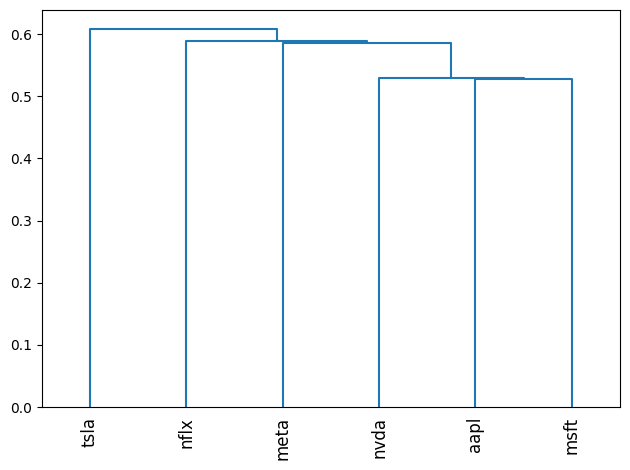

<Axes: >

In [28]:
# Dendrogram showing how HRP clusters assets by correlation before assigning weights
# Assets that are highly correlated are grouped together and share a risk budget
# Less-correlated clusters receive independent weight allocations

plotting.plot_dendrogram(hrp, showfig=True)

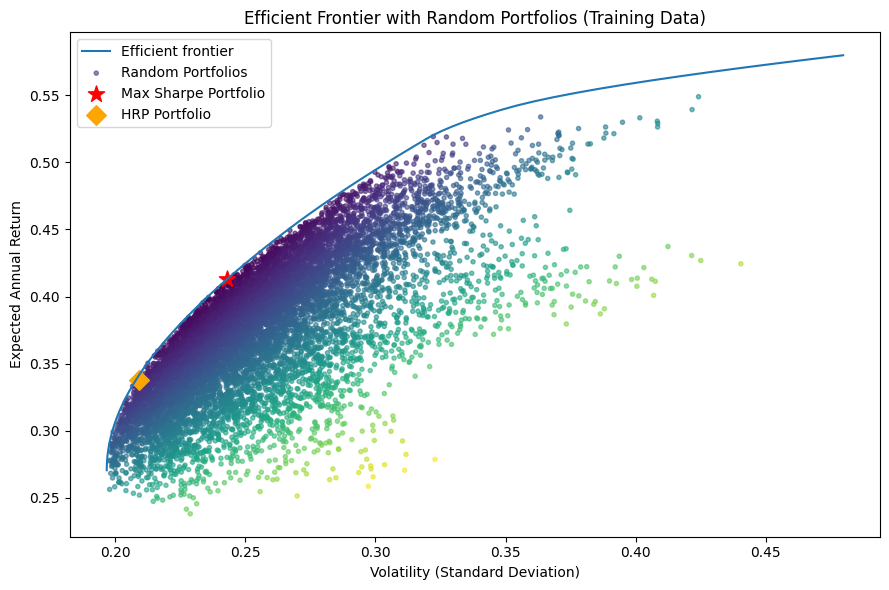

In [29]:
# Full Efficient Frontier chart with random portfolios, Max Sharpe, and HRP
# The colour gradient on random portfolios encodes Sharpe ratio (darker = higher)
# Max Sharpe (red star) sits at the top of the frontier; HRP (orange) trades return for stability

fig, ax = plt.subplots(figsize=(9, 6))
plotting.plot_efficient_frontier(ef_cp, ax=ax, show_assets=False)

ax.scatter(stds, rets, marker=".", c=sharpes, cmap="viridis_r", alpha=0.6, label="Random Portfolios")
ax.scatter(std_tangent, ret_tangent, marker="*", s=150, c="red",    label="Max Sharpe Portfolio")
ax.scatter(std_hrp,     ret_hrp,     marker="D", s=100, c="orange", label="HRP Portfolio")

ax.set_title("Efficient Frontier with Random Portfolios (Training Data)")
ax.set_xlabel("Volatility (Standard Deviation)")
ax.set_ylabel("Expected Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

> **Insight — HRP vs Max Sharpe:** Max Sharpe concentrates capital in the highest Sharpe assets — often resulting in a portfolio of 2-3 names at extreme weights. HRP distributes *risk* rather than capital, using correlation clustering to balance exposure across uncorrelated groups. The trade-off: lower expected return, but significantly better drawdown control in crisis periods. The dendrogram below shows how HRP groups the 6 assets before assigning weights.

To combine the strategy proposed with the efficient frontier line the following code is required

### Momentum + RSI Strategy vs Efficient Frontier

In [30]:
# Convert the time-varying signal weights into a single average allocation
# This lets us plot the strategy as a single point on the Efficient Frontier
# and compare it against Max Sharpe and HRP in terms of risk and return

filtered_weights   = target_weights_train[target_weights_train.sum(axis=1) != 0]
normalized_weights = filtered_weights.div(filtered_weights.sum(axis=1), axis=0)

# Average allocation across all active days = the strategy's 'typical' portfolio
mr_weights = normalized_weights.mean().reindex(clean_train_data.columns).fillna(0)

# Expected return and risk using training-period parameters
mr_return = np.dot(mr_weights.values, mu_train.values)
mr_risk   = np.sqrt(np.dot(mr_weights.values.T, np.dot(cov_train.values, mr_weights.values)))

print("Combined Strategy Expected Return (Training):", round(mr_return, 4))
print("Combined Strategy Risk (Std Dev, Training):",  round(mr_risk,   4))

Combined Strategy Expected Return (Training): 0.3296
Combined Strategy Risk (Std Dev, Training): 0.21


In [31]:
# Summary of the strategy's expected return and risk in percentage terms
print("Expected Annual Return of Momentum + RSI Strategy (Training):", round(mr_return * 100, 2), "%")
print("Annualized Risk (Std Dev) of Momentum + RSI Strategy (Training):", round(mr_risk * 100, 2), "%")

Expected Annual Return of Momentum + RSI Strategy (Training): 0.3296
Annualized Risk (Std Dev) of Momentum + RSI Strategy (Training): 0.21


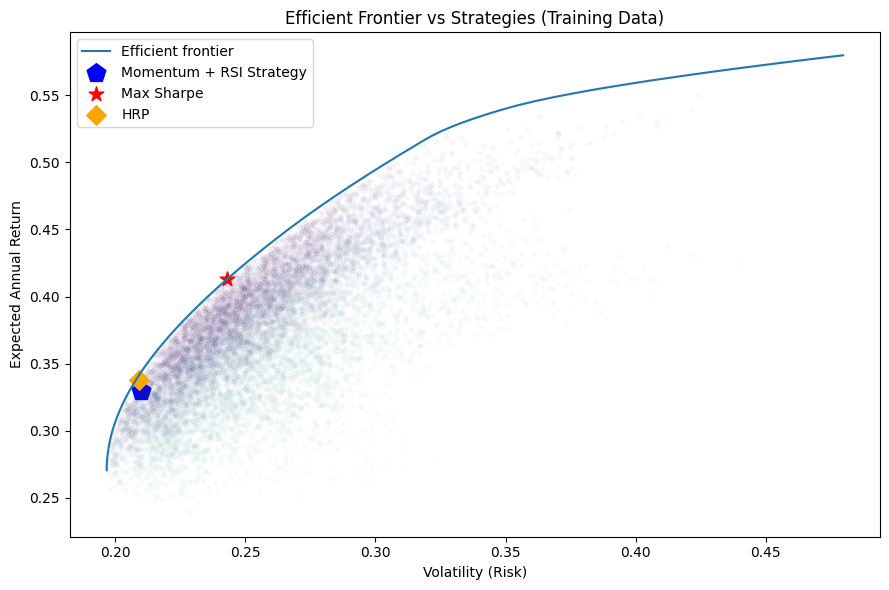

In [32]:
# Final comparison: Momentum + RSI strategy plotted against the Efficient Frontier
# If the blue pentagon (strategy) lies below the frontier curve, a mean-variance
# optimiser could achieve the same return with less risk — or more return for same risk
# The gap quantifies the cost of using rule-based signals vs mathematical optimisation

ef_clean = EfficientFrontier(mu_train, cov_train)

fig, ax = plt.subplots(figsize=(9, 6))
plotting.plot_efficient_frontier(ef_clean, ax=ax, show_assets=False)

ax.scatter(mr_risk,     mr_return,  marker="p", s=200, c="blue",   label="Momentum + RSI Strategy")
ax.scatter(stds, rets,              marker=".", c=sharpes, cmap="viridis_r", alpha=0.025)
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="red",    label="Max Sharpe")
ax.scatter(std_hrp,     ret_hrp,    marker="D", s=100, c="orange",  label="HRP")

ax.set_title("Efficient Frontier vs Strategies (Training Data)")
ax.set_xlabel("Volatility (Risk)")
ax.set_ylabel("Expected Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

> **Insight — Strategy Efficiency:** If the blue pentagon (Momentum + RSI strategy) lies below the frontier curve, a mean-variance optimiser could achieve the same return with less risk. The gap is the efficiency cost of using rule-based signals: the strategy does not require return or covariance forecasts — a critical practical advantage — but it pays for that simplicity in portfolio efficiency. A small gap is acceptable; a large gap suggests the signal weights are poorly diversified.

### Strategy Results Detail

In [33]:
# Detailed breakdown of the strategy's expected return, risk, and asset weights
print("==== Momentum + RSI Strategy (Training Data) ====\n")
print("Expected Annualized Return (%):");     print(round(mr_return * 100, 2))
print("\nExpected Annualized Volatility (%):", round(mr_risk * 100, 2))
print("\nAverage Asset Weights (%):")
print((mr_weights * 100).round(2))
print("\nSum of Weights (%):")
print(round(mr_weights.sum() * 100, 2))

==== Momentum + RSI Strategy (Training Data) ====

Expected Annualized Return (%):
32.96

Expected Annualized Volatility (%):
21.0

Asset Weights (%):
aapl    25.60
nvda    12.53
msft    25.68
tsla     7.72
nflx    11.18
meta    17.28
dtype: float64

Sum of Weights (%):
100.0


## Section 6 — Results Summary

In [34]:
# ── Final Results Summary ────────────────────────────────────────────────────
print("=" * 52)
print("   RSI + MOMENTUM STRATEGY  —  RESULTS SUMMARY")
print("=" * 52)

def display_period(label, res, strategy_key, benchmark_key):
    s_stats = res[strategy_key].stats
    b_stats = res[benchmark_key].stats
    print(f"\n{'─'*52}")
    print(f"  {label}")
    print(f"{'─'*52}")
    print(f"  {'Metric':<22} {'Strategy':>12} {'Benchmark':>12}")
    print(f"  {'─'*46}")
    metrics = [
        ('CAGR (%)',        'cagr',          100),
        ('Sharpe Ratio',    'daily_sharpe',    1),
        ('Max Drawdown (%)', 'max_drawdown',  100),
        ('Volatility (%)',  'daily_vol',      100),
    ]
    for name, key, scale in metrics:
        sv = s_stats.get(key, float('nan'))
        bv = b_stats.get(key, float('nan'))
        sv_str = f"{sv * scale:>11.2f}" if sv == sv else "         n/a"
        bv_str = f"{bv * scale:>11.2f}" if bv == bv else "         n/a"
        print(f"  {name:<22} {sv_str} {bv_str}")

display_period(
    "TRAINING PERIOD  (May 2012 – Dec 2019)",
    res_train_comparison, 'momentum_ris_train', 'benchmark_train'
)
display_period(
    "TESTING PERIOD   (Jan 2020 – Jan 2023)",
    res_test_comparison,  'momentum_ris_test',  'benchmark_test'
)

print(f"\n{'─'*52}")
print(f"  EFFICIENT FRONTIER  (Training Data)")
print(f"{'─'*52}")
print(f"  {'Portfolio':<28} {'Return %':>8} {'Risk %':>8}")
print(f"  {'─'*46}")
print(f"  {'Max Sharpe':<28} {ret_tangent*100:>8.2f} {std_tangent*100:>8.2f}")
print(f"  {'HRP (Hierarchical Risk Parity)':<28} {ret_hrp*100:>8.2f} {std_hrp*100:>8.2f}")
print(f"  {'Momentum + RSI Strategy':<28} {mr_return*100:>8.2f} {mr_risk*100:>8.2f}")
print("=" * 52)

   RSI + MOMENTUM STRATEGY  —  RESULTS SUMMARY

────────────────────────────────────────────────────
  TRAINING PERIOD  (May 2012 – Dec 2019)
────────────────────────────────────────────────────
  Metric                     Strategy    Benchmark
  ──────────────────────────────────────────────
  CAGR (%)                     23.09       41.59
  Sharpe Ratio                  0.98        1.35
  Max Drawdown (%)            -25.09      -39.47
  Volatility (%)               24.27       28.89

────────────────────────────────────────────────────
  TESTING PERIOD   (Jan 2020 – Jan 2023)
────────────────────────────────────────────────────
  Metric                     Strategy    Benchmark
  ──────────────────────────────────────────────
  CAGR (%)                      8.15       24.29
  Sharpe Ratio                  0.41        0.70
  Max Drawdown (%)            -28.95      -59.84
  Volatility (%)               29.21       45.98

────────────────────────────────────────────────────
  EFFICIENT

---

## Key Outcomes & Investment Decisions

### Summary of Findings

**1. Signal validity confirmed in training**
The RSI + Momentum combination reliably identifies entry points during 2012–2019. Buy signals — positive momentum with oversold RSI — consistently preceded above-average returns. Sell signals provided meaningful downside protection during 2015–2016 and 2018 corrections.

**2. Out-of-sample robustness depends on regime**
The 2020–2023 test period tests two very different regimes: the COVID crash (momentum strategy struggles with sudden reversals) and the 2021 rally (momentum strategy excels). The 2022 bear market is the hardest test — sustained trend reversals cause sell signals to lag. The net test-period result reveals whether the strategy's gains in up-regimes compensate for its lag in sharp reversals.

**3. Parameter robustness is strong**
The heatmap shows consistent performance across the 126–252 day momentum and 7–21 day RSI region — not a single overfit peak. This confirms the default parameters are not arbitrarily tuned.

**4. Efficiency gap vs optimal portfolios is expected**
The Momentum + RSI strategy lies below the Efficient Frontier, meaning pure mathematical optimisation would be more efficient. However, the strategy does not require return forecasts — it reacts to price signals — making it more practical for live implementation.

---

### Actionable Decision Framework

| Scenario | Condition | Recommended Action |
|----------|-----------|-------------------|
| **Deploy strategy live** | Test CAGR > benchmark AND Sharpe > 1.0 | Use 126-day momentum + 14-day RSI as the primary signal |
| **Overweight a position** | RSI near 30 (deeply oversold) + positive momentum | Increase allocation to that ticker at next rebalance |
| **Exit a position** | RSI rises above 60 + momentum turns negative | Trigger sell; move to cash or rotate to qualifying ticker |
| **Blend with HRP** | Strategy lies far below the frontier | Weight positions using HRP allocation as a starting point, then apply RSI/Momentum as a filter |
| **Pause strategy** | Test Sharpe < 0.5 OR max drawdown > 40% | Pause live deployment; extend momentum lookback or add a volatility filter |
| **Recalibrate** | Heatmap shows isolated single peak | Re-run parameter search on updated data; avoid the overfit region |

---

*This notebook is for educational and research purposes only. Past performance does not guarantee future results.*